In [21]:
# ==============================
# IMPORTS
# ==============================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gym
from gym import spaces
import matplotlib.pyplot as plt

In [22]:

# ==============================
# ENVIRONMENT (IMPROVED)
# ==============================
class TrafficEnv(gym.Env):
    def __init__(self):
        super(TrafficEnv, self).__init__()

        self.observation_space = spaces.Box(low=0, high=50, shape=(4,), dtype=np.float32)
        self.action_space = spaces.Discrete(4)

        self.state = np.random.randint(0, 10, size=(4,))

    def step(self, action):
        # Cars pass
        passed = np.random.randint(1, 5)
        self.state[action] = max(0, self.state[action] - passed)

        # Less randomness (IMPORTANT)
        self.state += np.random.randint(0, 2, size=(4,))

        # ✅ STRONGER reward
        reward = -np.sum(self.state)

        # bonus if lane cleared
        if self.state[action] == 0:
            reward += 5

        done = False
        return self.state.astype(np.float32), reward, done, {}

    def reset(self):
        self.state = np.random.randint(0, 10, size=(4,))
        return self.state.astype(np.float32)


In [23]:


# ==============================
# MODEL
# ==============================
class ActorCritic(nn.Module):
    def __init__(self, input_dim, action_dim):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 128)
        self.actor = nn.Linear(128, action_dim)
        self.critic = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        policy = F.softmax(self.actor(x), dim=-1)
        value = self.critic(x)
        return policy, value


In [24]:

# ==============================
# TRAINING
# ==============================
env = TrafficEnv()
model = ActorCritic(4, 4)

optimizer = optim.Adam(model.parameters(), lr=0.0001)
gamma = 0.99

num_episodes = 200

losses = []
episode_rewards = []

for episode in range(num_episodes):
    state = torch.FloatTensor(env.reset())

    log_probs = []
    values = []
    rewards = []

    for t in range(50):
        policy, value = model(state)

        dist = torch.distributions.Categorical(policy)
        action = dist.sample()

        next_state, reward, done, _ = env.step(action.item())

        log_probs.append(dist.log_prob(action))
        values.append(value)
        rewards.append(reward)

        state = torch.FloatTensor(next_state)

    # ==============================
    # RETURNS
    # ==============================
    returns = []
    G = 0

    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)

    returns = torch.tensor(returns, dtype=torch.float32)

    # normalize
    returns = (returns - returns.mean()) / (returns.std() + 1e-5)

    values = torch.stack(values).squeeze()
    advantage = returns - values

    # ==============================
    # LOSS
    # ==============================
    actor_loss = -(torch.stack(log_probs) * advantage.detach()).mean()
    critic_loss = advantage.pow(2).mean()

    loss = actor_loss + critic_loss

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
    optimizer.step()

    # ==============================
    # TRACKING
    # ==============================
    losses.append(loss.item())
    episode_rewards.append(sum(rewards))

    print(f"Episode {episode}, Loss: {loss.item():.2f}, Reward: {sum(rewards)}")


Episode 0, Loss: 7.41, Reward: -1515
Episode 1, Loss: 5.05, Reward: -1282
Episode 2, Loss: 4.47, Reward: -1180
Episode 3, Loss: 4.79, Reward: -1567
Episode 4, Loss: 8.23, Reward: -1721
Episode 5, Loss: 8.85, Reward: -2015
Episode 6, Loss: 2.11, Reward: -697
Episode 7, Loss: 4.06, Reward: -1126
Episode 8, Loss: 3.42, Reward: -894
Episode 9, Loss: 4.25, Reward: -1119
Episode 10, Loss: 3.45, Reward: -1180
Episode 11, Loss: 2.97, Reward: -1223
Episode 12, Loss: 4.34, Reward: -1396
Episode 13, Loss: 6.28, Reward: -1848
Episode 14, Loss: 1.83, Reward: -825
Episode 15, Loss: 1.86, Reward: -809
Episode 16, Loss: 2.62, Reward: -1368
Episode 17, Loss: 3.02, Reward: -1021
Episode 18, Loss: 5.04, Reward: -2209
Episode 19, Loss: 1.49, Reward: -797
Episode 20, Loss: 4.63, Reward: -1786
Episode 21, Loss: 3.58, Reward: -1481
Episode 22, Loss: 2.56, Reward: -1140
Episode 23, Loss: 0.90, Reward: -766
Episode 24, Loss: 2.81, Reward: -1800
Episode 25, Loss: 1.70, Reward: -974
Episode 26, Loss: 2.78, Rewar

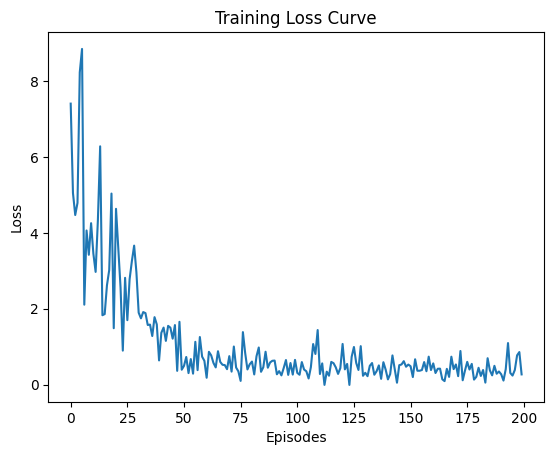

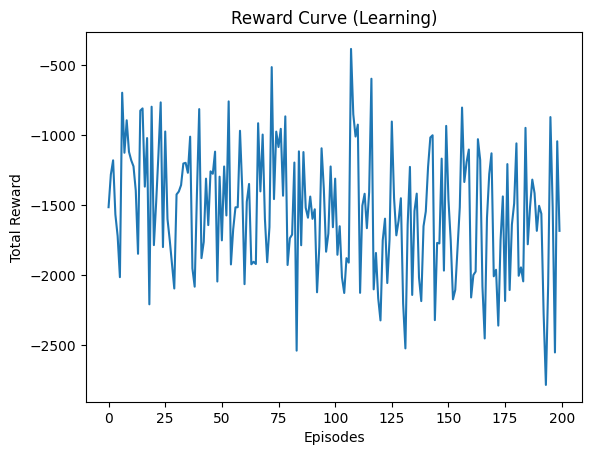

In [25]:

# ==============================
# PLOTTING
# ==============================

# LOSS GRAPH
plt.figure()
plt.plot(losses)
plt.xlabel("Episodes")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

# REWARD GRAPH (IMPORTANT)
plt.figure()
plt.plot(episode_rewards)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Reward Curve (Learning)")
plt.show()